# Шарафетдинов Ринат Домашнее задание 3

In [32]:
# Импорт библиотек
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, KFold, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor


import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# Фиксация зерна для экспериментов
seed = 42

## Preprocessing after EDA

In [3]:
df = pd.read_csv("/home/rinat/repos/itmo_mlsd_2024/notebooks/parsed_2024_12_28.csv", index_col=0)

In [4]:
df.head()

,name,description,employer_name,salary,schedule,key_skills,experience,employment,region_name
0,PHP-разработчик (Middle),Дром даёт возможность вместе с сильной командо...,Дром,180000.0,fullDay,"{PHP,ООП,Веб-программирование,MySQL}",between3And6,full,Томская область
1,Руководитель отдела продаж (Дистрибьюция),Компания &quot;АКВАСТОК&quot; - отечественный ...,АКВАСТОК,240000.0,fullDay,"{Активные продажи,Поиск и привлечение клиентов...",between3And6,full,Москва
2,Ведущий инженер-программист,Приглашаем на работу ВЕДУЩЕГО ИНЖЕНЕРА-ПРОГРАМ...,"Энергокабель, Завод",146500.0,fullDay,"{Python,MS SQL,SQL,MS Visual Studio,C/C++}",between1And3,full,Московская область
3,Инженер-программист,ПК «Аквариус» – ведущий российский разработчик...,"Аквариус, Группа компаний",75000.0,fullDay,NaN,noExperience,full,Москва
4,Программист С#,COMITAS — первый системный интегратор междунар...,КОМИТАС,155000.0,fullDay,"{АСУ ТП,C#,C++,Автоматизация,HMI,PostgreSQL}",between1And3,full,Москва


In [5]:
df.shape

(60000, 9)

In [6]:
df.dtypes

name              object
description       object
employer_name     object
salary           float64
schedule          object
key_skills        object
experience        object
employment        object
region_name       object
dtype: object

In [7]:
df.isna().sum()

name                0
description         0
employer_name       0
salary              0
schedule            0
key_skills       9605
experience          0
employment          0
region_name         0
dtype: int64

In [8]:
df = df.fillna("-")

In [9]:
df.describe()

,salary
count,6.000000e+04
mean,1.272537e+05
std,2.353379e+05
min,1.000000e+00
25%,8.000000e+04
50%,1.100000e+05
75%,1.600000e+05
max,5.505000e+07


In [10]:
# Удаляем выбросы по зарплате
df = df.loc[(df['salary'] > 10000) & (df['salary'] < 1000000)].reset_index(drop=True)

In [11]:
df.shape

(59881, 9)

# Feature engineering 

In [12]:
# Предобработка данных
def create_and_apply_mapping(df, columns):
    mappings = {}
    for column in columns:
        # Создание маппинга для столбца
        unique_values = df[column].unique()
        mapping = {value: idx for idx, value in enumerate(unique_values)}
        mappings[column] = mapping
        # Преобразование значений в тренировочном наборе
        df[column] = df[column].map(mapping)
        print(f"Mapping for {column}: {mapping}")
    return mappings

def apply_mapping(df, mappings):
    for column, mapping in mappings.items():
        # Применение существующего маппинга
        df[column] = df[column].map(mapping).fillna(-1).astype(int)
    return df

# Пример тренировочного набора
encoded_columns = ['schedule', 'experience', 'employment', 'region_name']
mappings = create_and_apply_mapping(df, encoded_columns)

Mapping for schedule: {'fullDay': 0, 'remote': 1, 'flexible': 2, 'shift': 3, 'flyInFlyOut': 4}
Mapping for experience: {'between3And6': 0, 'between1And3': 1, 'noExperience': 2, 'moreThan6': 3}
Mapping for employment: {'full': 0, 'probation': 1, 'part': 2, 'project': 3}
Mapping for region_name: {'Томская область': 0, 'Москва': 1, 'Московская область': 2, 'Санкт-Петербург': 3, 'Тюменская область': 4, 'Новосибирская область': 5, 'Пензенская область': 6, 'Республика Татарстан': 7, 'Республика Башкортостан': 8, 'Калининградская область': 9, 'Ленинградская область': 10, 'Псковская область': 11}


In [13]:
# Объединение текстовых полей (не удаляем спец. символы, они важны т.к. есть примеры: с++, c#, которые могуть удалиться из выборки)
def combine_text(row):
    text_fields = [str(row[col]).lower() for col in ["name", "description", "employer_name", "key_skills"]]
    return " ".join(text_fields)

df['combined_text'] = df.apply(combine_text, axis=1)

In [15]:
df['combined_text'].head().loc[0]

'php-разработчик (middle) дром даёт возможность вместе с сильной командой создавать высокотехнологичные продукты для миллионов пользователей на вебе и в мобильных приложениях. мы много вкладываемся в честный рынок и лучший пользовательский опыт. используем нейронные сети, которые помогают людям безопасно покупать автомобили. пишем рекомендательные сервисы на основе машинного обучения, они подбирают хорошие варианты для новичков и опытных автолюбителей, подсказывают нужные запчасти и даже учат сдавать на права. сейчас мы активно работаем над несколькими масштабными проектами, поэтому расширяем штат сотрудников и ищем опытных специалистов. дром — это автомобильный интернет-портал федерального уровня. ежедневно сайт посещает более 3 миллионов пользователей. нам 20 лет, и мы продолжаем активно расти. чем будем заниматься:  разрабатывать новые и поддерживать существующие сервисы; оптимизировать код под постоянно растущие нагрузки; участвовать в кодревью команды; обсуждать новые фичи и требо

In [16]:
# Создание эмбеддинга с использованием SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')  # Предобученная модель SentenceTransformer
embeddings = model.encode(df['combined_text'].tolist())

In [17]:
# Преобразование эмбеддинга в DataFrame
embeddings_df = pd.DataFrame(embeddings, columns=[f"embedding_{i}" for i in range(embeddings.shape[1])])

# Объединение эмбеддингов с исходным DataFrame
df = pd.concat([df, embeddings_df], axis=1).drop(columns=['combined_text', 'name', 'description', 'employer_name', 'key_skills'])

In [18]:
# Итоговый датасет
df.head()

,salary,schedule,experience,employment,region_name,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,...,embedding_374,embedding_375,embedding_376,embedding_377,embedding_378,embedding_379,embedding_380,embedding_381,embedding_382,embedding_383
0,180000.0,0,0,0,0,-0.054782,-0.020749,-0.008864,-0.054320,-0.015184,...,-0.023332,0.052232,-0.032877,0.034629,-0.009647,-0.066975,-0.019776,0.014471,-0.035292,-0.039396
1,240000.0,0,0,0,1,-0.049938,0.003367,0.010477,0.005836,-0.037794,...,-0.069875,0.067837,-0.004805,-0.074307,-0.044768,-0.012915,-0.002745,0.017519,-0.025438,-0.038108
2,146500.0,0,1,0,2,-0.019286,-0.036847,-0.047443,0.007828,-0.081888,...,-0.075455,0.075258,-0.032205,-0.049675,-0.022314,0.002440,-0.017521,0.004930,0.011542,-0.016541
3,75000.0,0,2,0,1,-0.027741,-0.015445,-0.068425,0.018001,-0.057119,...,-0.045196,0.054040,-0.011132,-0.082328,-0.059411,0.011900,-0.019630,-0.065100,-0.052771,-0.051061
4,155000.0,0,1,0,1,-0.034219,0.003833,-0.005521,-0.032232,-0.074323,...,-0.066778,0.060881,-0.006141,-0.015030,-0.042200,-0.009000,-0.029395,-0.001967,-0.019171,-0.050569


# Training models

In [19]:
# Обозначаем данные для обучения моделей
X = df.drop(['salary'], axis=1)
y = df['salary']

In [20]:
# Настройка кросс-валидации
kf = KFold(n_splits=3, shuffle=True, random_state=seed)

In [31]:
# Функция для подбора гиперпараметров Random Forest
def tune_random_forest(X, y):
    param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 5, 7, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    rf_model = RandomForestRegressor(random_state=seed, n_jobs=-1)
    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X, y)
    print("Best parameters for Random Forest:", grid_search.best_params_)
    print("Best score for Random Forest:", grid_search.best_score_)
    return grid_search.best_estimator_

# Подбор гиперпараметров для Random Forest
best_rf_model = tune_random_forest(X, y)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best score for Random Forest: -0.40025250343102603


In [ ]:
# Функция для подбора гиперпараметров CatBoost
def tune_catboost(X, y):
    param_grid = {
        'iterations': [200, 300, 400, 500, 700, 1000, 1500, 2000, 2250, 2500, 3000],
        'depth': [3, 5, 7, 10],
        'learning_rate': [0.05, 0.1, 0.2, 0.25, 0.3],
        'l2_leaf_reg': [2, 3, 5, 7]
    }
    cat_model = CatBoostRegressor(random_seed=seed, silent=True)
    grid_search = GridSearchCV(
        estimator=cat_model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X, y)
    print("Best parameters for CatBoost:", grid_search.best_params_)
    print("Best score for CatBoost:", grid_search.best_score_)
    return grid_search.best_estimator_


# Подбор гиперпараметров для CatBoost
best_cat_model = tune_catboost(X, y)

Best parameters for CatBoost: {'depth': 10, 'iterations': 500, 'l2_leaf_reg': 2, 'learning_rate': 0.25}
Best score for CatBoost: -0.28313641007933127


In [33]:
# Модель 1: Линейная регрессия
linear_model = LinearRegression()
linear_pred = cross_val_predict(linear_model, X, y, cv=kf)
linear_mape = mean_absolute_percentage_error(y, linear_pred)
print(f"Linear Regression MAPE: {linear_mape:.4f}")

Linear Regression MAPE: 0.4398


In [34]:
# Модель 2: Random Forest (с подобранными гиперпараметрами)
rf_pred = cross_val_predict(best_rf_model, X, y, cv=kf)
rf_mape = mean_absolute_percentage_error(y, rf_pred)
print(f"Random Forest MAPE: {rf_mape:.4f}")

Random Forest MAPE: 0.4003


In [ ]:
# Модель 3: CatBoost (с подобранными гиперпараметрами)
cat_pred = cross_val_predict(best_cat_model, X, y, cv=kf, method='predict')
cat_mape = mean_absolute_percentage_error(y, cat_pred)
print(f"CatBoost MAPE: {cat_mape:.4f}")

CatBoost MAPE: 0.2831


In [36]:
# Модель 4: Gradient Boosting Sklearn
gb_model = GradientBoostingRegressor(random_state=seed)
gb_pred = cross_val_predict(gb_model, X, y, cv=kf)
gb_mape = mean_absolute_percentage_error(y, gb_pred)
print(f"Gradient Boosting MAPE: {gb_mape:.4f}")

Gradient Boosting MAPE: 0.4040


# Visual Model

In [47]:
model = CatBoostRegressor(depth=10, learning_rate=0.25, n_estimators=500, l2_leaf_reg=2, task_type="GPU", devices='0:1', random_seed=seed)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [49]:
model.fit(X_train, y_train)

0:	learn: 64918.0323479	total: 126ms	remaining: 1m 2s
1:	learn: 62492.0447353	total: 257ms	remaining: 1m 4s
2:	learn: 60800.4736922	total: 384ms	remaining: 1m 3s
3:	learn: 59470.6826374	total: 507ms	remaining: 1m 2s
4:	learn: 58762.0986106	total: 633ms	remaining: 1m 2s
5:	learn: 58065.0987036	total: 749ms	remaining: 1m 1s
6:	learn: 57538.8752851	total: 865ms	remaining: 1m
7:	learn: 57092.3735904	total: 985ms	remaining: 1m
8:	learn: 56526.0151400	total: 1.11s	remaining: 1m
9:	learn: 56075.7081871	total: 1.24s	remaining: 1m
10:	learn: 55749.5832963	total: 1.35s	remaining: 1m
11:	learn: 55377.1316039	total: 1.48s	remaining: 1m
12:	learn: 55054.5882890	total: 1.6s	remaining: 1m
13:	learn: 54743.4559391	total: 1.73s	remaining: 1m
14:	learn: 54508.2296586	total: 1.85s	remaining: 59.8s
15:	learn: 54245.6776389	total: 1.97s	remaining: 59.5s
16:	learn: 54083.1585849	total: 2.08s	remaining: 59.1s
17:	learn: 53746.5554076	total: 2.2s	remaining: 58.9s
18:	learn: 53567.2664913	total: 2.32s	remainin

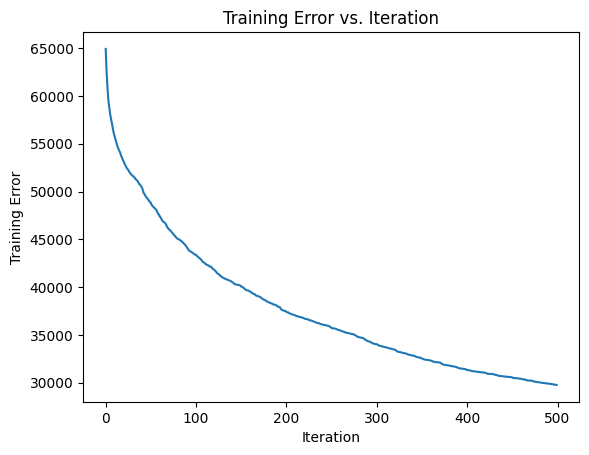

In [50]:
# Загрузка данных об ошибке обучения из файла
train_error = pd.read_csv('catboost_info/learn_error.tsv', sep='\t')

# Построение графика ошибки обучения
plt.plot(train_error['iter'], train_error['RMSE'])
plt.xlabel('Iteration')
plt.ylabel('Training Error')
plt.title('Training Error vs. Iteration')
plt.show()

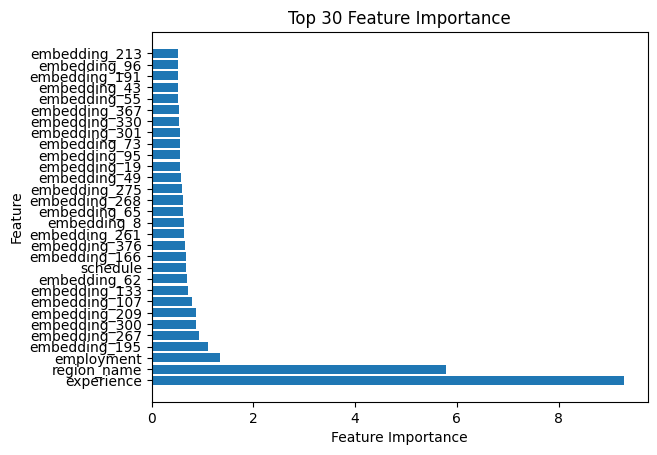

In [51]:
# Получение важности признаков из обученной модели
feature_importance = model.feature_importances_

# Создание DataFrame с важностью признаков
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})

# Сортировка признаков по их важности
importance_df = importance_df.sort_values(by='Importance', ascending=False)

top_n = 30  # Количество наиболее важных признаков, которые нужно отобразить

plt.barh(importance_df['Feature'][:top_n], importance_df['Importance'][:top_n])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top {} Feature Importance'.format(top_n))
plt.show()

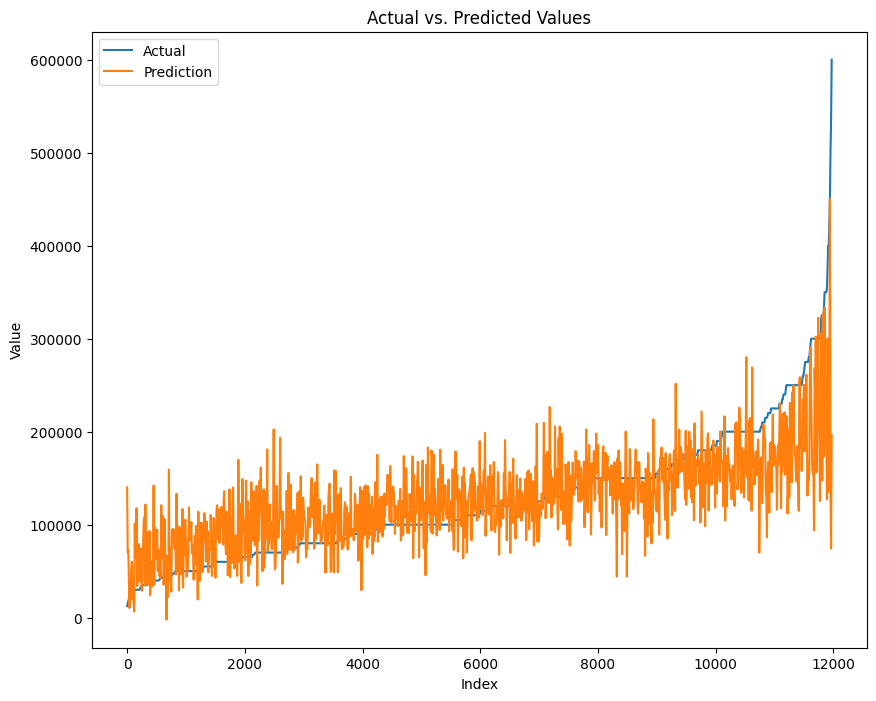

In [52]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Получение индексов, которые отсортируют y_test от меньшего к большему
sorted_indexes = np.argsort(y_test)

# Сортировка y_test и y_test_pred
sorted_y_test = y_test.iloc[sorted_indexes]
sorted_y_test_pred = y_test_pred[sorted_indexes]

N = 10  # Отображать каждый N-й элемент
plt.figure(figsize=(10, 8))  # Установка размера графика (10 дюймов по ширине, 8 дюймов по высоте)

# Создание индексов для отображения каждого N-го элемента
indexes = range(0, len(sorted_y_test), N)

# Отображение только каждого N-го элемента на графике
plt.plot(indexes, sorted_y_test.iloc[indexes], label='Actual')
plt.plot(indexes, sorted_y_test_pred[indexes], label='Prediction')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.show()
